In [1]:
import numpy as np
import numba as nb
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib as mpl

%load_ext autoreload
%autoreload 2

import sys, os
sys.path.append('..')

%matplotlib inline

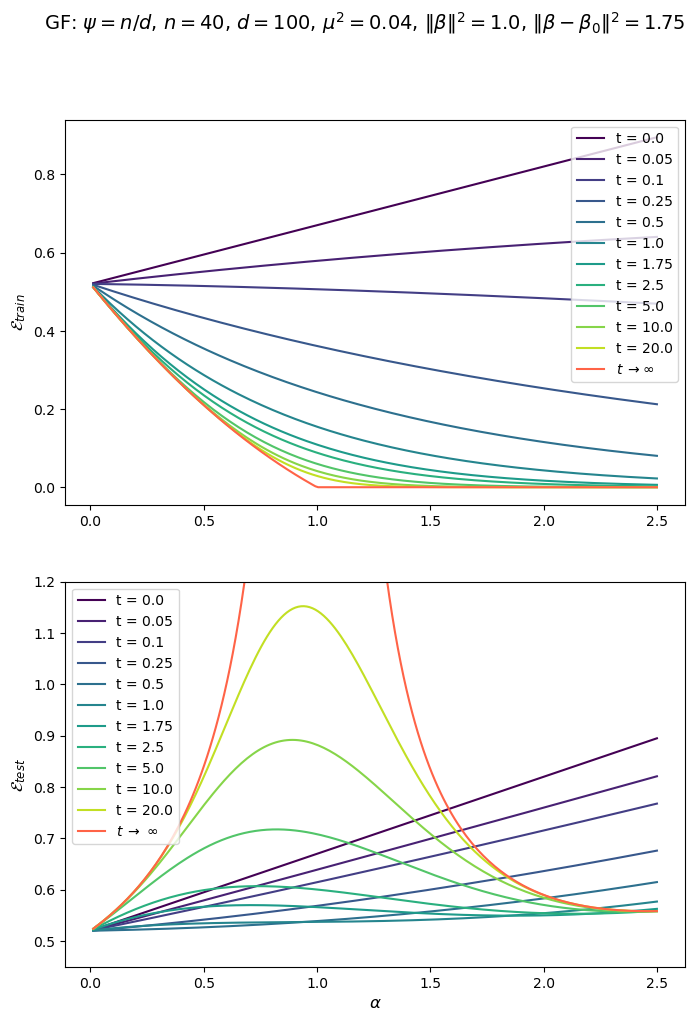

In [2]:
from theory.theory import legacy_GF_test_error, legacy_GF_test_error_inf_time, \
    GF_train_error, GF_train_error_inf_time_precise

n = 40
d = 100
psi = d / n
mu2 = 0.04
betadiff2 = 1.75
beta2 = 1.
n_alpha_points = 200
alpha = np.linspace(0, psi, n_alpha_points)[1:]

lr = 10 ** (-2)
t = [0, 5, 10, 25, 50, 100, 175, 250, 500, 1e3, 2 * 1e3]

Etest_gf_old = np.stack([
    legacy_GF_test_error(alpha, psi, mu2, tval * lr, betadiff2, beta2=beta2) for tval in t
])
Etest_gf_old_inft = legacy_GF_test_error_inf_time(alpha, psi, mu2, betadiff2, beta2=beta2)


cmap_viridis = mpl.colormaps['viridis']
plt.figure(figsize=(8, 11))
ax1 = plt.subplot(211)
for i, tval in enumerate(t):
    ax1.plot(alpha, GF_train_error(alpha, psi, mu2, tval * lr, betadiff2, beta2=beta2),
             c=cmap_viridis(i / len(t)), label=f't = {tval * lr}')
ax1.set_ylabel('$\\mathcal{{E}}_{{train}}$', fontsize=12)
ax1.plot(alpha, GF_train_error_inf_time_precise(alpha * n, n, d, mu2, beta2=beta2),
         label='$t \\; \\to \\infty$', c='tomato')
ax1.legend()

ax2 = plt.subplot(212)
for i, tval in enumerate(t):
    ax2.plot(alpha, Etest_gf_old[i],
             c=cmap_viridis(i / len(t)), label=f't = {tval * lr}')
ax2.plot(alpha, Etest_gf_old_inft, label='$t \\; \\to \\; \\infty$', c='tomato')
ax2.set_ylim((0.45, 1.2))
ax2.legend()  

ax2.set_ylabel('$\\mathcal{{E}}_{{test}}$', fontsize=12)
ax2.set_xlabel('$\\alpha$', fontsize=12)
plt.suptitle(f'GF: $\\psi = n/d$, $ n = {n}$, $d={d}$, $\\mu^2 = {mu2}$,'
             f' $\\|\\beta \\|^2 = {beta2}$, $\\|\\beta - \\beta_0 \\|^2 = {betadiff2}$', fontsize=14)
plt.show()

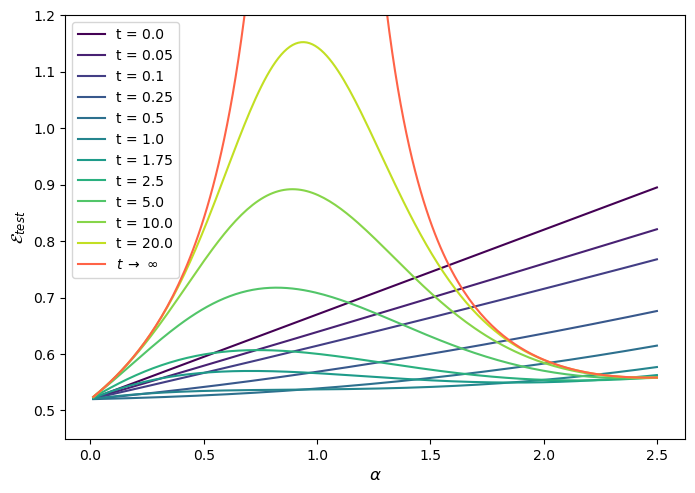

In [3]:
from theory.theory import GF_test_error, GF_test_error_inf_time

# For comparison with old plots
n = 40
d = 100
psi = d / n
mu2 = 0.04
betadiff2 = 1.75
beta2 = 1
n_alpha_points = 200
alpha = np.linspace(0, psi, n_alpha_points)[1:]


lr = 10 ** (-2)
t = np.array([0, 5, 10, 25, 50, 100, 175, 250, 500, 1e3, 2 * 1e3])
Etest_gf = GF_test_error(alpha[np.newaxis, :], (t * lr)[:, np.newaxis], psi=psi, betadiff2=betadiff2, beta2=beta2, mu2=mu2)
Etest_gf_inft = GF_test_error_inf_time(alpha, psi=psi, betadiff2=betadiff2, beta2=beta2, mu2=mu2)


cmap_viridis = mpl.colormaps['viridis']
plt.figure(figsize=(8, 5.5))
for i, tval in enumerate(t):
    plt.plot(alpha, Etest_gf[i], c=cmap_viridis(i / len(t)), label=f't = {tval * lr}')
plt.plot(alpha, Etest_gf_inft,
         label='$t \\; \\to \\; \\infty$', c='tomato')
plt.ylim((0.45, 1.2))
plt.legend()  

plt.ylabel('$\\mathcal{{E}}_{{test}}$', fontsize=12)
plt.xlabel('$\\alpha$', fontsize=12);

In [4]:
assert np.allclose(Etest_gf, Etest_gf_old)
assert np.allclose(Etest_gf_inft, Etest_gf_old_inft)